In [ ]:
 pip install -q ultralytics

In [ ]:
!pip install -q kaggle

from google.colab import files

print("Upload your kaggle.json file:")
uploaded = files.upload()

Upload your kaggle.json file:


Saving kaggle.json to kaggle.json


In [ ]:
!kaggle datasets download -d aklimarimi/8-facial-expressions-for-yolo

Dataset URL: https://www.kaggle.com/datasets/aklimarimi/8-facial-expressions-for-yolo
License(s): apache-2.0
100% 3.77G/3.77G [00:38<00:00, 104MB/s]



In [ ]:
import zipfile
import os

zip_path = "/content/8-facial-expressions-for-yolo.zip"
extract_path = "/content/original_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

print("\nMain folders:")
for item in os.listdir(extract_path):
    print("-", item)

Dataset extracted successfully!

Main folders:
- 9 Facial Expressions you need


In [ ]:
import os

dataset_path = "/content/original_dataset/9 Facial Expressions you need"

print("Dataset contents:\n")

for item in os.listdir(dataset_path):
    print("-", item)

Dataset contents:

- train
- valid
- test
- data.yaml


In [ ]:
import os

dataset_path = "/content/original_dataset/9 Facial Expressions you need"

for split in ["train", "valid", "test"]:
    image_dir = os.path.join(dataset_path, split, "images")
    label_dir = os.path.join(dataset_path, split, "labels")

    images = [
        f for f in os.listdir(image_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    labels = [
        f for f in os.listdir(label_dir)
        if f.endswith(".txt")
    ]

    print(f"{split.upper()}:")
    print(f"  Images: {len(images)}")
    print(f"  Labels: {len(labels)}")

TRAIN:
  Images: 64864
  Labels: 64866
VALID:
  Images: 1720
  Labels: 1720
TEST:
  Images: 1700
  Labels: 1700


In [ ]:
import os
import shutil
import random

random.seed(42)

source = "/content/original_dataset/9 Facial Expressions you need"
target = "/content/emotion_small"

# Create folders
for split in ["train", "valid", "test"]:
    os.makedirs(f"{target}/{split}/images", exist_ok=True)
    os.makedirs(f"{target}/{split}/labels", exist_ok=True)

# Required number of images
sizes = {
    "train": 7000,
    "valid": 1000,
    "test": 1000
}

for split, required in sizes.items():

    image_dir = f"{source}/{split}/images"
    label_dir = f"{source}/{split}/labels"

    images = [
        f for f in os.listdir(image_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
        and os.path.exists(
            os.path.join(label_dir, os.path.splitext(f)[0] + ".txt")
        )
    ]

    random.shuffle(images)
    selected = images[:required]

    for image in selected:
        label = os.path.splitext(image)[0] + ".txt"

        shutil.copy2(
            os.path.join(image_dir, image),
            os.path.join(target, split, "images", image)
        )

        shutil.copy2(
            os.path.join(label_dir, label),
            os.path.join(target, split, "labels", label)
        )

    print(f"{split.upper()}: {len(selected)} images copied")

print("\nSmall dataset created successfully!")
print("Location:", target)

TRAIN: 7000 images copied
VALID: 1000 images copied
TEST: 1000 images copied

Small dataset created successfully!
Location: /content/emotion_small


In [ ]:
import yaml

data = {
    "train": "/content/emotion_small/train/images",
    "val": "/content/emotion_small/valid/images",
    "test": "/content/emotion_small/test/images",
    "nc": 9,
    "names": [
        "angry",
        "contempt",
        "disgust",
        "fear",
        "happy",
        "natural",
        "sad",
        "sleepy",
        "surprised"
    ]
}

yaml_path = "/content/emotion_small/data.yaml"

with open(yaml_path, "w") as f:
    yaml.dump(data, f, sort_keys=False)

print("data.yaml created successfully!")
print("\nClasses:", data["names"])
print("Number of classes:", data["nc"])
print("Dataset:", "/content/emotion_small")

data.yaml created successfully!

Classes: ['angry', 'contempt', 'disgust', 'fear', 'happy', 'natural', 'sad', 'sleepy', 'surprised']
Number of classes: 9
Dataset: /content/emotion_small


In [ ]:
import os

dataset_path = "/content/emotion_small"

for split in ["train", "valid", "test"]:
    image_dir = os.path.join(dataset_path, split, "images")
    label_dir = os.path.join(dataset_path, split, "labels")

    images = [
        f for f in os.listdir(image_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    labels = [
        f for f in os.listdir(label_dir)
        if f.endswith(".txt")
    ]

    print(f"{split.upper()}:")
    print(f"  Images : {len(images)}")
    print(f"  Labels : {len(labels)}")
    print(f"  Match  : {len(images) == len(labels)}")
    print()

TRAIN:
  Images : 7000
  Labels : 7000
  Match  : True

VALID:
  Images : 1000
  Labels : 1000
  Match  : True

TEST:
  Images : 1000
  Labels : 1000
  Match  : True



In [ ]:
from ultralytics import YOLO
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

model = YOLO("yolo11n.pt")

print("\nYOLO model loaded successfully!")

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4

YOLO model loaded successfully!


In [ ]:
results = model.train(
    data="/content/emotion_small/data.yaml",
    epochs=10,
    imgsz=416,
    batch=16,
    device=0,
    workers=2,
    project="/content/emotion_training",
    name="facial_emotion_yolo"
)

Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/emotion_small/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=facial_emotion_yolo, nbs=64,

In [ ]:
import os

print("Checking saved project files...\n")

paths = [
    "/content/emotion_small",
    "/content/emotion_training",
    "/content/emotion_training/facial_emotion_yolo/weights/best.pt"
]

for path in paths:
    print(f"{path}: {'FOUND' if os.path.exists(path) else 'NOT FOUND'}")

Checking saved project files...

/content/emotion_small: FOUND
/content/emotion_training: FOUND
/content/emotion_training/facial_emotion_yolo/weights/best.pt: FOUND


In [ ]:
from ultralytics import YOLO

best_model = YOLO(
    "/content/emotion_training/facial_emotion_yolo/weights/best.pt"
)

test_results = best_model.val(
    data="/content/emotion_small/data.yaml",
    split="test",
    imgsz=416,
    batch=16,
    device=0,
    project="/content/emotion_test",
    name="test_results"
)

print("\nTEST EVALUATION COMPLETED!")

Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,583,907 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1071.6±558.2 MB/s, size: 72.4 KB)
val: Scanning /content/emotion_small/test/labels... 1000 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1000/1000 1.4Kit/s 0.7s
val: New cache created: /content/emotion_small/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 63/63 5.9it/s 10.7s
                   all       1000       1000      0.531       0.55      0.587      0.431
                 angry        186        186      0.597      0.494       0.62      0.474
              contempt         36         36      0.361      0.417      0.474       0.36
               disgust         67         67      0.535      0.478      0.573      0.496
                  fear         84         84      0.531      0.655 

In [ ]:
from ultralytics import YOLO
import os

best_model = YOLO(
    "/content/emotion_training/facial_emotion_yolo/weights/best.pt"
)

test_images = "/content/emotion_small/test/images"

results = best_model.predict(
    source=test_images,
    imgsz=416,
    conf=0.4,
    device=0,
    save=True,
    project="/content/emotion_predictions",
    name="test_predictions"
)

print("\nPrediction completed!")
print("Predictions saved to:")
print("/content/emotion_predictions/test_predictions")


image 1/1000 /content/emotion_small/test/images/01a6c69e76d729863380b8391d780e53070cf8629ad9ffd5d06826551271fe74_-_30_-_-_20201207110113-004-010_jpg.rf.12ba6581114cf2ec0fd5d8985deab55f.jpg: 416x416 1 happy, 8.3ms
image 2/1000 /content/emotion_small/test/images/01a6c69e76d729863380b8391d780e53070cf8629ad9ffd5d06826551271fe74_-_30_-_-_20201207110113-004-010_jpg.rf.631c7a13b4faff84a0e80fcc01dc2528.jpg: 416x416 1 happy, 9.3ms
image 3/1000 /content/emotion_small/test/images/01a6c69e76d729863380b8391d780e53070cf8629ad9ffd5d06826551271fe74_-_30_-_-_20201207110120-005-003_jpg.rf.769a6101de49c89d9b9e0479b6bcfb1a.jpg: 416x416 1 happy, 8.4ms
image 4/1000 /content/emotion_small/test/images/01a6c69e76d729863380b8391d780e53070cf8629ad9ffd5d06826551271fe74_-_30_-_-_20201207110120-005-018_jpg.rf.2cdee083b98a0bc6c36409057f466b91.jpg: 416x416 1 happy, 9.1ms
image 5/1000 /content/emotion_small/test/images/01a6c69e76d729863380b8391d780e53070cf8629ad9ffd5d06826551271fe74_-_30_-_-_20201207110131-007-009_jp

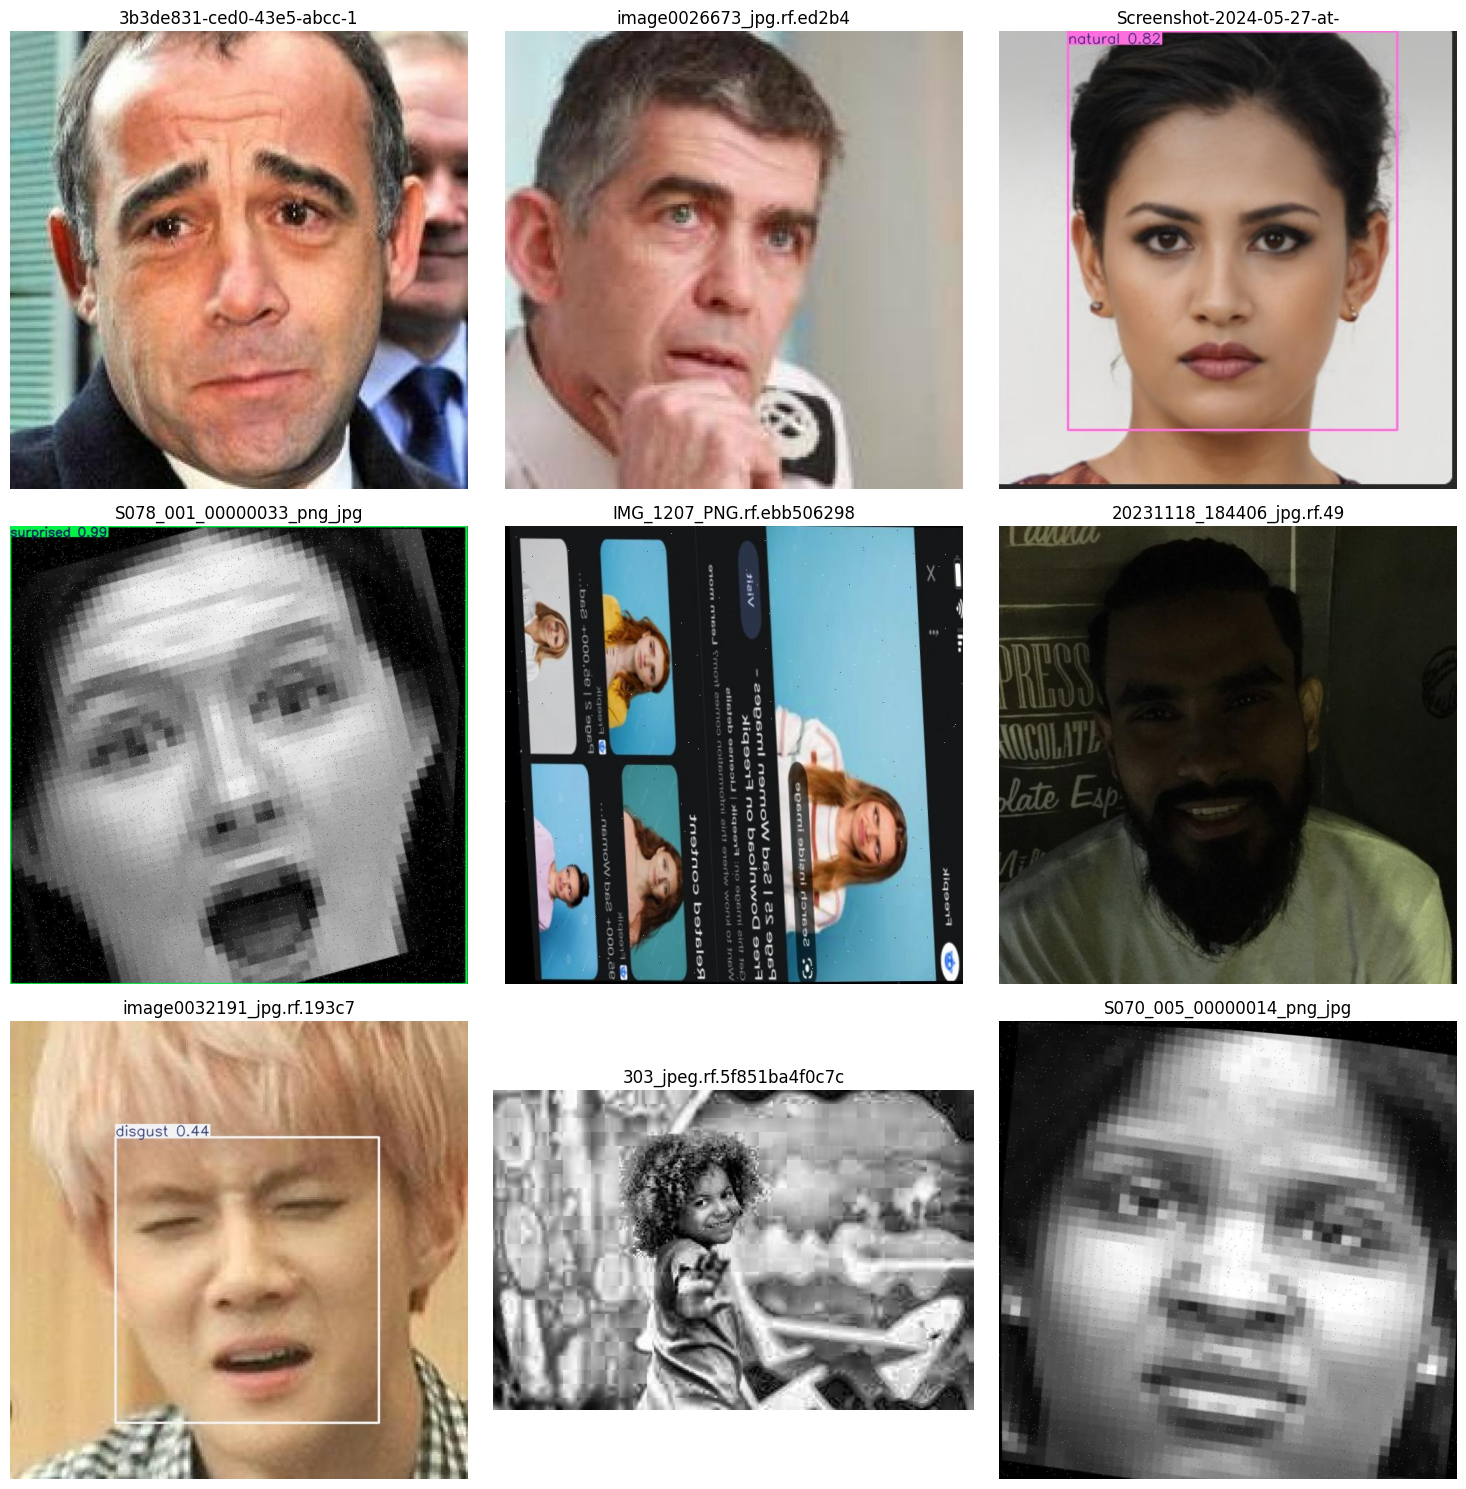

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import os
import random

prediction_dir = "/content/emotion_predictions/test_predictions"

images = [
    f for f in os.listdir(prediction_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

random.seed(42)
sample_images = random.sample(images, min(9, len(images)))

plt.figure(figsize=(15, 15))

for i, image_name in enumerate(sample_images):
    img = Image.open(os.path.join(prediction_dir, image_name))

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(image_name[:25])

plt.tight_layout()
plt.show()

In [ ]:
from ultralytics import YOLO
import os

model = YOLO(
    "/content/emotion_training/facial_emotion_yolo/weights/best.pt"
)

class_names = [
    "angry",
    "contempt",
    "disgust",
    "fear",
    "happy",
    "natural",
    "sad",
    "sleepy",
    "surprised"
]

image_dir = "/content/emotion_small/test/images"
label_dir = "/content/emotion_small/test/labels"

results = model.predict(
    source=image_dir,
    imgsz=416,
    conf=0.4,
    device=0,
    verbose=False
)

correct = 0
wrong = 0
no_detection = 0

print("ACTUAL vs PREDICTION\n")

for result in results:
    image_name = os.path.basename(result.path)
    label_file = os.path.splitext(image_name)[0] + ".txt"
    label_path = os.path.join(label_dir, label_file)

    with open(label_path, "r") as f:
        actual_class = int(f.readline().split()[0])

    actual = class_names[actual_class]

    if len(result.boxes) > 0:
        predicted_class = int(result.boxes.cls[0])
        confidence = float(result.boxes.conf[0])
        predicted = class_names[predicted_class]

        if predicted_class == actual_class:
            correct += 1
            status = "CORRECT"
        else:
            wrong += 1
            status = "WRONG"

        print(
            f"{image_name[:35]:35} | "
            f"Actual: {actual:10} | "
            f"Prediction: {predicted:10} | "
            f"Confidence: {confidence:.2f} | {status}"
        )

    else:
        no_detection += 1
        print(
            f"{image_name[:35]:35} | "
            f"Actual: {actual:10} | "
            f"Prediction: NO DETECTION"
        )

print("\n==============================")
print("COMPARISON SUMMARY")
print("==============================")
print("Correct predictions :", correct)
print("Wrong predictions   :", wrong)
print("No detection        :", no_detection)

ACTUAL vs PREDICTION

01a6c69e76d729863380b8391d780e53070 | Actual: happy      | Prediction: happy      | Confidence: 0.96 | CORRECT
01a6c69e76d729863380b8391d780e53070 | Actual: happy      | Prediction: happy      | Confidence: 0.94 | CORRECT
01a6c69e76d729863380b8391d780e53070 | Actual: happy      | Prediction: happy      | Confidence: 0.94 | CORRECT
01a6c69e76d729863380b8391d780e53070 | Actual: happy      | Prediction: happy      | Confidence: 0.80 | CORRECT
01a6c69e76d729863380b8391d780e53070 | Actual: happy      | Prediction: happy      | Confidence: 0.95 | CORRECT
01a6c69e76d729863380b8391d780e53070 | Actual: happy      | Prediction: NO DETECTION
01a6c69e76d729863380b8391d780e53070 | Actual: happy      | Prediction: happy      | Confidence: 0.96 | CORRECT
040386c0-39ec-449a-862b-47ea96de6d3 | Actual: surprised  | Prediction: NO DETECTION
04a1c851-43a5-42bf-8960-4dfaa062454 | Actual: surprised  | Prediction: NO DETECTION
0a9d34ff118aca8feadb6a3f3b07e7d6f5f | Actual: happy      | P

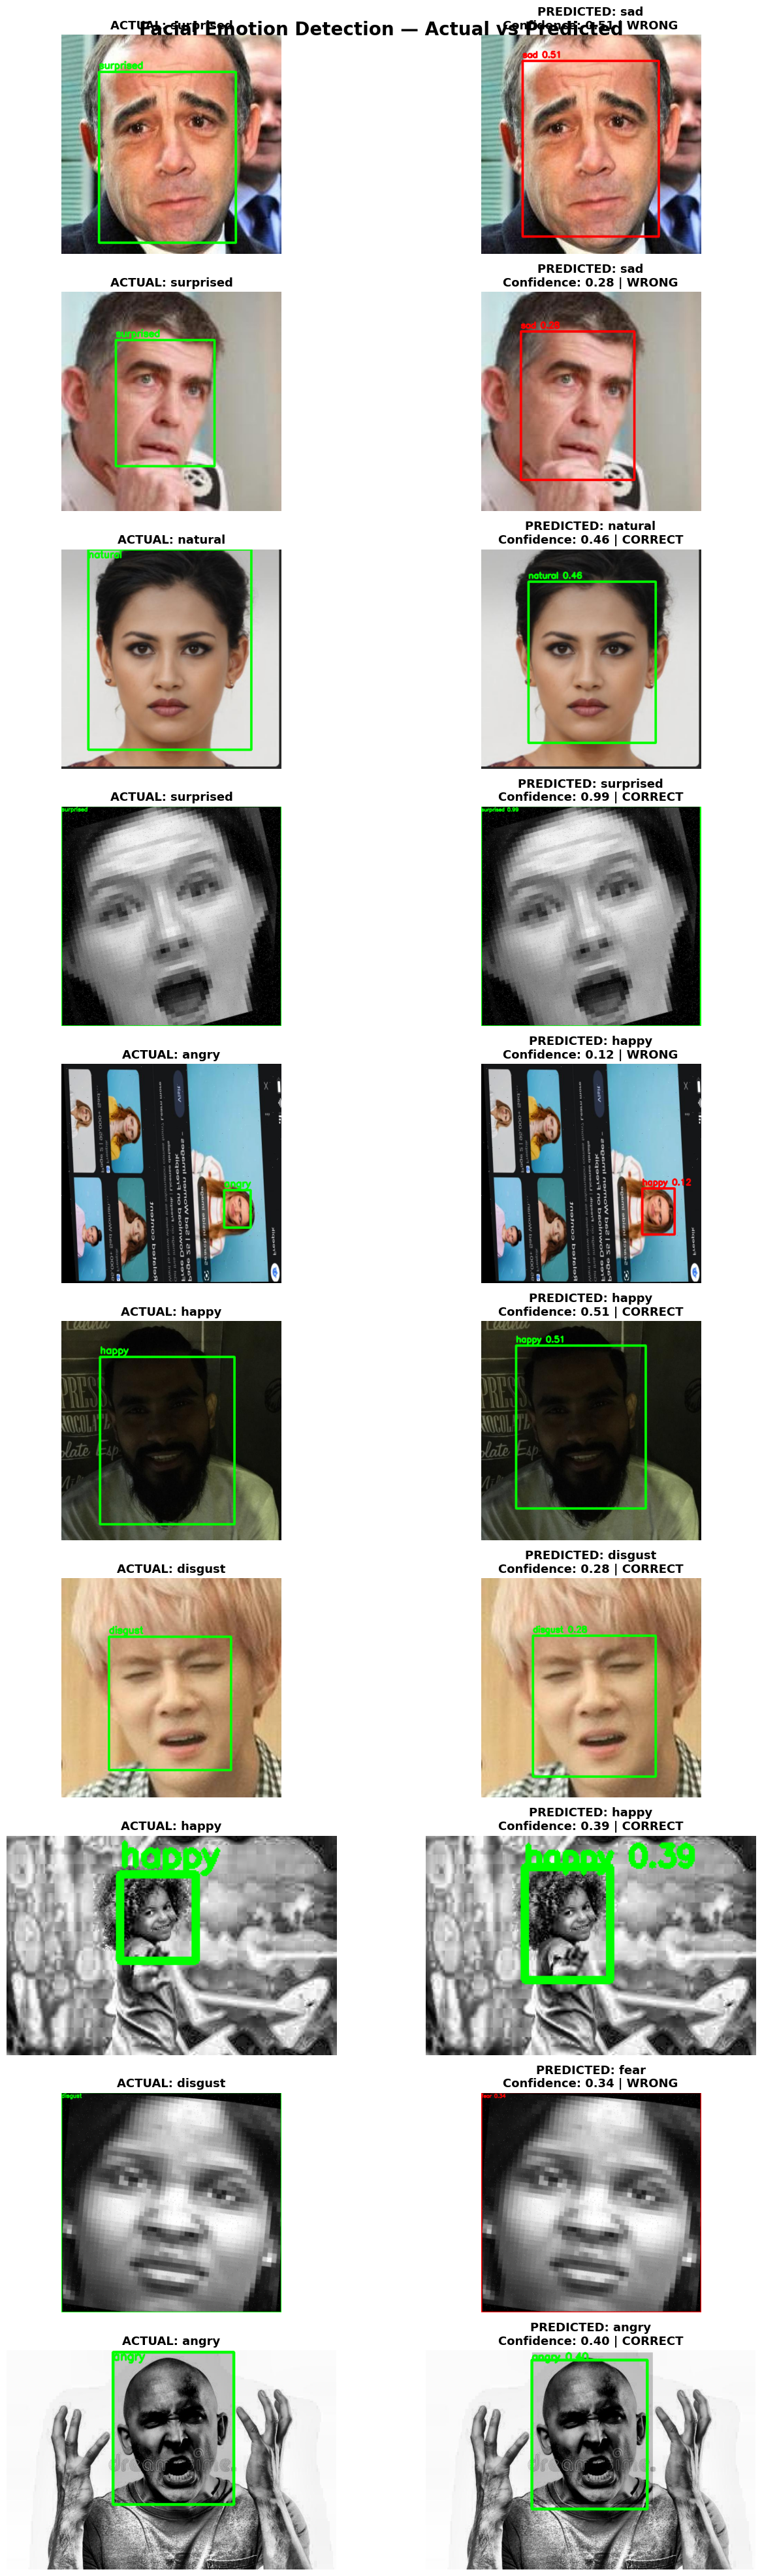

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import os
import random

model = YOLO(
    "/content/emotion_training/facial_emotion_yolo/weights/best.pt"
)

class_names = [
    "angry", "contempt", "disgust", "fear", "happy",
    "natural", "sad", "sleepy", "surprised"
]

image_dir = "/content/emotion_small/test/images"
label_dir = "/content/emotion_small/test/labels"

image_files = [
    f for f in os.listdir(image_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

random.seed(42)
sample_images = random.sample(image_files, 10)

fig, axes = plt.subplots(10, 2, figsize=(14, 40))

for row, image_name in enumerate(sample_images):

    image_path = os.path.join(image_dir, image_name)
    label_path = os.path.join(
        label_dir,
        os.path.splitext(image_name)[0] + ".txt"
    )

    original = cv2.imread(image_path)
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

    h, w = original.shape[:2]

    # ---------------- ACTUAL ----------------
    actual_image = original.copy()

    with open(label_path, "r") as f:
        label = f.readline().split()

    actual_class = int(label[0])
    actual = class_names[actual_class]

    # YOLO format: class x_center y_center width height
    x_center, y_center, box_w, box_h = map(float, label[1:5])

    x1 = int((x_center - box_w / 2) * w)
    y1 = int((y_center - box_h / 2) * h)
    x2 = int((x_center + box_w / 2) * w)
    y2 = int((y_center + box_h / 2) * h)

    cv2.rectangle(
        actual_image,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        5
    )

    cv2.putText(
        actual_image,
        actual,
        (x1, max(y1 - 10, 25)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.9,
        (0, 255, 0),
        3
    )

    # ---------------- PREDICTION ----------------
    prediction_image = original.copy()

    result = model.predict(
        original,
        imgsz=416,
        conf=0.10,
        device=0,
        verbose=False
    )[0]

    predicted = "No detection"
    confidence = 0.0

    if len(result.boxes) > 0:

        best = result.boxes.conf.argmax()

        predicted_class = int(result.boxes.cls[best])
        confidence = float(result.boxes.conf[best])
        predicted = class_names[predicted_class]

        box = result.boxes.xyxy[best].cpu().numpy().astype(int)
        px1, py1, px2, py2 = box

        if predicted_class == actual_class:
            color = (0, 255, 0)
            status = "CORRECT"
        else:
            color = (255, 0, 0)
            status = "WRONG"

        cv2.rectangle(
            prediction_image,
            (px1, py1),
            (px2, py2),
            color,
            5
        )

        cv2.putText(
            prediction_image,
            f"{predicted} {confidence:.2f}",
            (px1, max(py1 - 10, 25)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            color,
            3
        )

    else:
        status = "NO DETECTION"

    # ---------------- DISPLAY ----------------

    axes[row, 0].imshow(actual_image)
    axes[row, 0].set_title(
        f"ACTUAL: {actual}",
        fontsize=13,
        fontweight="bold"
    )
    axes[row, 0].axis("off")

    axes[row, 1].imshow(prediction_image)
    axes[row, 1].set_title(
        f"PREDICTED: {predicted}\n"
        f"Confidence: {confidence:.2f} | {status}",
        fontsize=13,
        fontweight="bold"
    )
    axes[row, 1].axis("off")

plt.suptitle(
    "Facial Emotion Detection — Actual vs Predicted",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving IMG-20250627-WA0108.jpg to IMG-20250627-WA0108.jpg


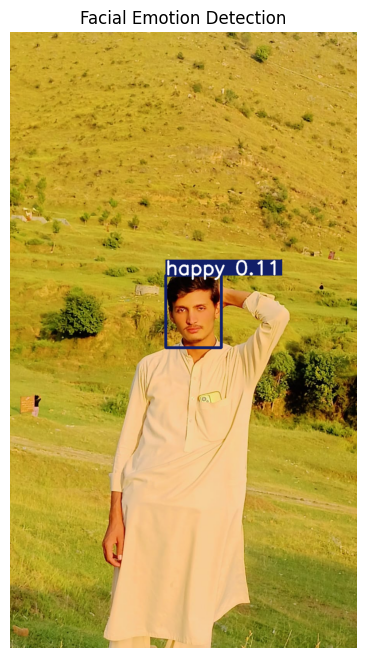

Emotion: happy
Confidence: 0.11


In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import os

model = YOLO(
    "/content/emotion_training/facial_emotion_yolo/weights/best.pt"
)

image_name = list(uploaded.keys())[0]

results = model.predict(
    source=image_name,
    imgsz=416,
    conf=0.10,
    device=0,
    verbose=False
)

result = results[0]

# Plot prediction
annotated = result.plot(
    line_width=5,
    font_size=1.2
)

annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))
plt.imshow(annotated)
plt.axis("off")
plt.title("Facial Emotion Detection")
plt.show()

# Print prediction details
if len(result.boxes) > 0:
    for box in result.boxes:
        class_id = int(box.cls[0])
        confidence = float(box.conf[0])
        emotion = model.names[class_id]

        print(f"Emotion: {emotion}")
        print(f"Confidence: {confidence:.2f}")
else:
    print("No face/emotion detected.")